<a href="https://colab.research.google.com/github/fmssilva/DL_Proj/blob/main/assignment_1/task3/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Pokemon Type Classification | DL Assignment 1

## Task 3 — Transfer Learning and Fine-Tuning

**Goal:** classify 3600 Pokémon images into 9 types using transfer learning techniques as well as fine-tunning strategies. The performance will be compared against the MLP from Task 1 and the CNN from Task 2.

**Metric:** Macro-averaged F1 — used because class imbalance is 2.76× (Water 674 vs Ground 244). Accuracy would be misleading.

_____________
**DO NOT RUN ALL CELLS**

> This notebook requires some 40 minutes to run all training sequences with T4 GPU. So if you don't have those resources, avoid running it all again and **instead just run the needed specific cells you want.**
______

---
## Table of Contents

- [Part 0 — Project Load](#part-0---project-load)
  - [Config](#config)
  - [Import & Set Up](#import--set-up)
  - [Load Data](#load-data)
- [Part 1 — Model Experiments](#part-1--model-experiments)
  - [Results Manager](#results-manager)
  - [Setup Experiments](#setup-experiments)
  - [Experiments Plan & Registry](#experiments-plan--registry)
  - [A: Trans Baseline - Efficient net b0](#a-trans-baseline---efficient-net-b0)
  - [B: VGG 16](#b-vgg-16)
  - [C: Swin V2 t](#c-swin-v2-t)
  - [D: ResNet34](#d-resnet34)
  - [E: ConvNext tiny](#e-convnext-tiny)
- [Part 2 — Pre-Processing & Data Augmentation](#part-3--pre-processing--data-augmentation)
  - [2.1 — Pre-Processing: Grayscale](#21--pre-processing-grayscale)
  - [2.2 — Data Augmentation Exploration](#22--data-augmentation-exploration)
- [Part 3 — Comparison, Final Model & Evaluation](#part-3--comparison-final-model--evaluation)
  - [3.1: Soft Ensemble Exploration](#31-soft-ensemble-exploration)
  - [3.2: All Models Summary](#32-all-models-summary)
  - [3.3: Comparison Between Best CNN and MLP Models](#33-comparison-between-best-cnn-and-mlp-models)
  - [3.4: Best Model Deep Dive](#34-best-solo-model-deep-dive)
- [Final Summary & Submission](#final-summary--submission)

---

**About the code:**

> This notebook is the runner + readable story.

> This notebook clones the repo from github, downloads the data from google drive, runs the code cells, during which saves results to the outputs folder and at the end does the automatic download of that folder.

> All reusable logic lives in `src/`.
> - `src/models/mlp.py` — 7 MLP classes: MLP, VanillaMLP, VanillaMLP_v2, NarrowMLP, WiderMLP, BottleneckMLP, DeepMLP — all with `in_channels` param (RGB=3 or grayscale=1)
> - `src/models/cnn.py` — 7 CNN classes: LeNet5, CNN, MediumCNN, DeepCNN, WideCNN, MultiScaleCNN, ResidualCNN — all with `in_channels` param (RGB=3 or grayscale=1)
> - `src/datasets/dataset.py` — RGB, augmented, grayscale, and gray+equalize transform pipelines; `grayscale`/`equalize` params in loaders
> - `src/training/early_stopping.py` — metric-agnostic, monitors by minimisation (`stopper(-val_f1, model)`)
> - `src/evaluation/metrics.py`, `plots.py`, `submission.py` — classification report, training curves, confusion matrix, submission CSV
> - `src/evaluation/ensemble.py` — soft ensemble with `inference_mode` for test-set inference (test labels are uuid strings, not ints)
> - `src/evaluation/persistence.py` — `save_outputs`/`restore_outputs` (Drive backup), `download_and_extract` (dataset download), `restore_tracker` (load prior results)
> - Tests: `models_test.py` (14), `dataset_test.py` (14), `train_test.py` (3) — all pass locally


**AI Assistance Disclosure**

> Artificial intelligence tools (Claude, ChatGPT, GitHub Copilot) were used strategically to enhance development efficiency while maintaining full academic integrity and authorship responsibility. AI assistance was limited to:

> - Debugging & testing — writing unit tests, identifying bugs and validating expected behaviours across the codebase

> - Visualisation & reporting — implementing plots and formatting results for clarity and readability, and adding comments to document the code

> All core concepts, research methodology, architectural decisions, and algorithmic implementations were conceived and developed by the authors.


# Part 0 - Project Load

### Config

In [97]:
#import wandb
#wandb.init()

In [98]:
# All run-level constants live HERE.
# Change FAST_RUN to switch between a quick smoke-test and a real Colab run.
# Nothing else needs touching.


# ==============  FLIP THESE FLAGS  ===============================
FAST_RUN         = False   # True = smoke-test (tiny data, 2 epochs) | False = real Colab run
SAVE_IN_EACH_RUN = False   # True = zip outputs to DRIVE_OUTPUTS_DIR after every experiment
USE_DRIVE        = False   # True = enable save/restore of outputs zip (Drive on Colab, local folder elsewhere)
# =================================================================

# === Task identifier — change this ONE constant when copying the notebook for Task 2 / Task 3.
TASK_NAME = "task3"

# ==== Drive / backup settings =====================================
# Shared Drive folder that holds the dataset zip and output backups.
# Anyone-with-the-link public share URL — no hardcoded personal MyDrive paths.
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing"

# Name of the dataset zip inside DRIVE_FOLDER_URL.
DATA_FILE_NAME = "the-pokemon-are-out-there-2026-task-2.zip"

# Name of the outputs zip inside DRIVE_FOLDER_URL.
OUTPUTS_FILE_NAME = TASK_NAME + "_outputs.zip"

# Where to save/restore the outputs zip:
#   Colab → inside your personal MyDrive (auto-mounted)
#   Local → any local folder (created automatically if needed)
import sys as _sys
DRIVE_OUTPUTS_DIR = (
    "/content/drive/MyDrive/DL_Proj"
    if "google.colab" in _sys.modules
    else str(__import__("pathlib").Path.home() / "DL_Proj")
)


# ======== Training hyperparams =============================================
EPOCHS      = 2     if FAST_RUN else 30
# PATIENCE: val_macro_f1 is noisier than val_loss (small val set → 1 mis-prediction
# swings F1 by ~1.2%). Use PATIENCE=7 to avoid stopping too early on noisy F1 plateaus.
PATIENCE    = 1     if FAST_RUN else 7
LR          = 1e-3
BATCH_SIZE  = 32    if FAST_RUN else 64
IMG_SIZE    = 64    # MLP input: 64x64x3 = 12288 flat features
NUM_WORKERS = 8

# smoke-test data size: 9 classes × N = total training images
N_SAMPLES_PER_CLASS = 6   # 54 total — enough to run the full pipeline in seconds

print(f"TASK_NAME         : {TASK_NAME}")
print(f"FAST_RUN          : {FAST_RUN}  (N_SAMPLES_PER_CLASS={N_SAMPLES_PER_CLASS if FAST_RUN else 'all'})")
print(f"EPOCHS            : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE        : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"USE_DRIVE         : {USE_DRIVE}  |  SAVE_IN_EACH_RUN : {SAVE_IN_EACH_RUN}")
print(f"DRIVE_FOLDER_URL  : {DRIVE_FOLDER_URL}")
print(f"DRIVE_OUTPUTS_DIR : {DRIVE_OUTPUTS_DIR}")


TASK_NAME         : task3
FAST_RUN          : False  (N_SAMPLES_PER_CLASS=all)
EPOCHS            : 30  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE        : 64  |  IMG_SIZE : 64x64
USE_DRIVE         : False  |  SAVE_IN_EACH_RUN : False
DRIVE_FOLDER_URL  : https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing
DRIVE_OUTPUTS_DIR : /content/drive/MyDrive/DL_Proj


### Import & Set Up

> Includes the autoreload, to automatically reload the src modules before every cell run, so if we edit some src/ file, we don't need to restart the kernel and loose all our state.

> This works locally. If we are running the notebook in colab, and we change the src files locally, so we need to push those changes to GitHub and then run the cell bellow for colab to go and get those new src/ files.

In [99]:
# ── PROJECT IMPORT AND SET UP ─────────────────────────────────────────────────────────

import sys, os, time, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if not IN_COLAB:
  %load_ext autoreload
  %autoreload 2

if IN_COLAB:
    if not os.path.exists("/content/DL_Proj"):
        !git clone https://github.com/fmssilva/DL_Proj.git /content/DL_Proj
    else:
        !git -C /content/DL_Proj pull --ff-only
    os.chdir("/content/DL_Proj/assignment_1")
    %pip install -r requirements.txt -q
else:
    # notebook kernel starts in task1/ — step up to assignment_1/ root
    cwd = Path(os.getcwd())
    if cwd.name.startswith("task"):
        os.chdir(cwd.parent)

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    SEED, CLASSES, NUM_CLASSES, DATA_DIR, OUT_DIR,
    get_task_out_dir, set_seed,
)

set_seed(SEED)

TASK_OUT_DIR = get_task_out_dir(TASK_NAME)
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH     = DATA_DIR / "train_labels.csv"
TRAIN_DIR    = DATA_DIR / "Train"
TEST_DIR     = DATA_DIR / "Test"

# auto-detect number of CPU cores for DataLoader workers (safe on Colab and local)
import multiprocessing
NUM_WORKERS = min(NUM_WORKERS, multiprocessing.cpu_count())

print("-"*50)
print(f"ROOT        : {ROOT}")
print(f"TASK_NAME   : {TASK_NAME}  |  TASK_OUT_DIR : {TASK_OUT_DIR}")
print(f"EPOCHS      : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"NUM_WORKERS : {NUM_WORKERS}")
print(f"Device      : {device}  |  PyTorch {torch.__version__}")
print(f"Outputs     : {TASK_OUT_DIR.resolve()}")


remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 460 bytes | 230.00 KiB/s, done.
From https://github.com/fmssilva/DL_Proj
   60ddcc7..2eb03e7  main       -> origin/main
Updating 60ddcc7..2eb03e7
Fast-forward
 assignment_1/src/models/transfer.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)
--------------------------------------------------
ROOT        : /content/DL_Proj/assignment_1
TASK_NAME   : task3  |  TASK_OUT_DIR : task3/outputs
EPOCHS      : 30  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE  : 64  |  IMG_SIZE : 64x64
NUM_WORKERS : 2
Device      : cuda  |  PyTorch 2.10.0+cu128
Outputs     : /content/DL_Proj/assignment_1/task3/outputs


### Hot Reload

> If we did chnges in src/ files and pushed to GitHub, now we just need to run this cell for colab to pull the new files.

In [100]:
import importlib
import sys
from pathlib import Path

if IN_COLAB:
    # pull latest code from GitHub before reloading
    import os
    os.chdir(Path(ROOT).parent)
    os.system("git pull --ff-only")
    os.chdir(ROOT)

# reload every src.* module that is already loaded in this kernel
_reloaded, _skipped = [], []
for mod_name, mod in list(sys.modules.items()):
    if mod_name.startswith("src.") and hasattr(mod, "__file__") and mod.__file__:
        try:
            importlib.reload(mod)
            _reloaded.append(mod_name)
        except Exception as e:
            print(f"  [WARN] could not reload {mod_name}: {e}")
            _skipped.append(mod_name)

print(f"Reloaded {len(_reloaded)} src modules: {_reloaded}")
if _skipped:
    print(f"Skipped  {len(_skipped)}: {_skipped}")


Reloaded 13 src modules: ['src.config', 'src.evaluation', 'src.evaluation.persistence', 'src.datasets', 'src.datasets.dataset', 'src.models', 'src.models.transfer', 'src.training', 'src.evaluation.metrics', 'src.training.train', 'src.training.early_stopping', 'src.evaluation.plots', 'src.evaluation.submission']


### Load Data

In [101]:
from src.evaluation.persistence import download_and_extract

# Download and extract the dataset if not already present.
# Uses DRIVE_FOLDER_URL + DATA_FILE_NAME from Config — works on Colab and locally.
if not Path("data/train_labels.csv").exists():
    ok = download_and_extract(DRIVE_FOLDER_URL, DATA_FILE_NAME, "data/")
    if not ok:
        print(
            "ERROR: data download failed.\n"
            f"  Folder : {DRIVE_FOLDER_URL}\n"
            f"  File   : {DATA_FILE_NAME}\n"
            "  Check that the folder is publicly shared and the file name is correct."
        )
else:
    print("data/ already present — skipping download")


df_full = pd.read_csv(CSV_PATH)
print(f"Full dataset : {len(df_full)} rows, {df_full['label'].nunique()} classes")

# FAST_RUN: subsample N per class so every cell finishes fast on CPU
if FAST_RUN:
    df = df_full.groupby("label", group_keys=False).head(N_SAMPLES_PER_CLASS).reset_index(drop=True)
    print(f"FAST_RUN     : subsampled to {len(df)} rows ({N_SAMPLES_PER_CLASS}/class)")
else:
    df = df_full

print(f"\nClass counts used this run:\n{df['label'].value_counts().to_string()}")

data/ already present — skipping download
Full dataset : 3600 rows, 9 classes

Class counts used this run:
label
Water       674
Normal      606
Poison      467
Fire        381
Bug         374
Grass       299
Fighting    291
Rock        264
Ground      244


# Part 1 — Model Experiments

## Results Manager
> This global dictionary keeps track of the models we train along the notebook, so it is easy to keep track and compare all models we train.

> This global dictionary with models results can be initialized empty, or we can choose to upload some previous output zip folder that we have, so we update this global results manager dictionary with all the models we got in previous runs.

**Run this cell only if you want to upload the saved task_outputs.zip from google drive and restore the results_tracker dictionary with that data.**

In [102]:
from src.evaluation.persistence import restore_outputs

# Restore previous outputs from Drive/local backup.
# On Colab  : mounts Drive and reads from DRIVE_OUTPUTS_DIR (private mounted path).
# Locally   : downloads from DRIVE_FOLDER_URL (public shared folder).
# Skip entirely when USE_DRIVE=False — nothing to restore.

if USE_DRIVE:
    backup_dir = DRIVE_OUTPUTS_DIR if IN_COLAB else DRIVE_FOLDER_URL
    restore_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, backup_dir=backup_dir)
else:
    print("[restore] USE_DRIVE=False — skipping restore, starting fresh.")

[restore] USE_DRIVE=False — skipping restore, starting fresh.


In [103]:
from src.evaluation.persistence import restore_tracker, ResultsTracker

# ResultsTracker = dict[str, ExperimentEntry]
# Each entry has these keys (see ExperimentEntry in persistence.py):
#   val_macro_f1 : float  — best val macro-F1 from the saved checkpoint
#   val_acc      : float  — val accuracy at that checkpoint
#   val_loss     : float  — val loss at that checkpoint (nan for ensembles)
#   total_epochs : int    — epochs actually run (< EPOCHS if early-stopped; 0 for ensembles)
#   train_time_s : float  — wall-clock training time in seconds (0.0 for ensembles)
#   history      : dict   — {"train_loss": [...], "val_loss": [...], "train_f1": [...], "val_f1": [...]}
#   child_models : list   — only present on ensemble entries; names of the averaged solo models
results_tracker: ResultsTracker = {}

results_json_path = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"

def _print_leaderboard(tracker: ResultsTracker) -> None:
    """Show all experiments sorted by val_macro_f1 descending as a styled DataFrame."""
    if not tracker:
        return
    rows = sorted(tracker.items(), key=lambda x: x[1]["val_macro_f1"], reverse=True)
    data = [
        {
            "rank":    rank,
            "name":    name,
            "val_F1":  round(m["val_macro_f1"], 4),
            "val_acc": round(m["val_acc"], 4),
            "epochs":  m["total_epochs"],
            "time(s)": round(m["train_time_s"], 1),
        }
        for rank, (name, m) in enumerate(rows, 1)
    ]
    df_lb = pd.DataFrame(data).set_index("rank")
    try:
        from IPython.display import display
        styled = (
            df_lb.style
            .background_gradient(subset=["val_F1"], cmap="RdYlGn", vmin=0.10, vmax=df_lb["val_F1"].max())
            .background_gradient(subset=["val_acc"], cmap="Blues", vmin=0.10, vmax=df_lb["val_acc"].max())
            .format({"val_F1": "{:.4f}", "val_acc": "{:.4f}", "time(s)": "{:.1f}"})
        )
        display(styled)
    except Exception:
        # terminal / non-Jupyter fallback
        print(df_lb.to_string())


print("-" * 50)
restore_tracker(results_json_path, results_tracker)
print("Current experiments in results_tracker:")
_print_leaderboard(results_tracker)


--------------------------------------------------
Restored 5 experiments from task3/outputs/results/task3_results.json
Current experiments in results_tracker:


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans,0.6873,0.6819,29,494.7
2,D_trans,0.4198,0.4486,22,131.2
3,C_trans,0.3260,0.3375,30,233.6
4,A_trans,0.2955,0.3333,28,182.7
5,E_trans,0.2583,0.3056,30,196.2


## Setup Experiments
These helper cells define the shared infrastructure used by every experiment:
- **`build_loaders(augment, use_sampler, grayscale, equalize)`** — wraps `get_train_val_loaders`, always uses `df` (which can be the subsampled FAST_RUN set)
- **`run_experiment(model, name, criterion, optimizer, scheduler, loaders)`** — full train loop, early stopping on `val_macro_f1`, checkpoint save, evaluate best, store in `results_tracker` and immediately upsert to `task2_results.json`

Each experiment cell is then just 4–5 lines: instantiate model, criterion, optimizer, scheduler → call `run_experiment`.

In [104]:

# ── Shared imports for all experiment cells ───────────────────────────────────
import torch.nn as nn
from torch.utils.data import DataLoader
from src.datasets.dataset import (
    PokemonDataset, compute_class_weights,
    get_base_transforms, get_gray_transforms, get_train_val_loaders,
)
from src.models.transfer import EfficientNetB0Transfer, VGG_16_Transfer, Swin_V2_t_Transfer, ResNet34_Transfer, ConvNext_tiny_Transfer
from src.training.train import train_one_epoch, evaluate
from src.training.early_stopping import EarlyStopping
from src.evaluation.metrics import classification_report_str
from src.evaluation.plots import plot_history, plot_confusion_matrix
from src.evaluation.persistence import save_experiment_result, save_all_results, save_outputs
from src.evaluation.submission import generate_submission_from_preds, validate_submission

import time

# build class weights from the run's df (correct proportions even for FAST_RUN)
label_to_idx     = {cls: i for i, cls in enumerate(CLASSES)}
_all_train_labels = [label_to_idx[lbl] for lbl in df["label"]]
class_weights    = compute_class_weights(_all_train_labels).to(device)

# test loader is always the full test set — not touched until submission
test_ds     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE), csv_path=None)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# single path for incremental per-experiment saves and final save_all_results
RESULTS_PATH = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"
SUB_PATH     = TASK_OUT_DIR / "results" / f"submission_{TASK_NAME}.csv"

print(f"Test images  : {len(test_ds)}")
print(f"Class weights: { {cls: round(class_weights[i].item(), 3) for i, cls in enumerate(CLASSES)} }")


# ── Helper: build_loaders ─────────────────────────────────────────────────────
def build_loaders(augment: bool = False, use_sampler: bool = False,
                  grayscale: bool = False, equalize: bool = False):
    """Return (train_loader, val_loader) for the current df and hyperparams.
    grayscale=True → (1,H,W) tensors, input_dim=4096. equalize=True → histogram stretch before gray."""
    return get_train_val_loaders(
        CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
        augment=augment, use_sampler=use_sampler,
        num_workers=NUM_WORKERS, df_override=df,
        grayscale=grayscale, equalize=equalize,
    )


# pre-build the two standard loader pairs used by all Part 2 experiments
loaders_base    = build_loaders(augment=False, use_sampler=False)
loaders_sampler = build_loaders(augment=False, use_sampler=True)


# ── Helper: _make_test_loader ─────────────────────────────────────────────────
def _make_test_loader(stem: str) -> DataLoader:
    """Return a test DataLoader with the correct transform for the given experiment stem.
    Gray experiments need grayscale transforms; all others use the standard RGB transform."""
    if stem.endswith("_gray_eq"):
        t = get_gray_transforms(IMG_SIZE, equalize=True)
    elif stem.endswith("_gray"):
        t = get_gray_transforms(IMG_SIZE, equalize=False)
    else:
        return test_loader   # reuse the global RGB test loader
    ds = PokemonDataset(TEST_DIR, t, csv_path=None)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


# ── Helper: _is_new_overall_best ─────────────────────────────────────────────
def _is_new_overall_best(name: str, f1: float) -> bool:
    """True if this experiment (solo or ensemble) beats every other entry in results_tracker.
    Compares against all existing entries so the CSV is only updated when we truly have a new top."""
    other_f1s = [v["val_macro_f1"] for k, v in results_tracker.items() if k != name]
    return f1 > max(other_f1s, default=-1)


# ── Helper: run_experiment ────────────────────────────────────────────────────
def run_experiment(model, name: str, criterion, optimizer, scheduler, loaders) -> tuple:
    """
    Train model up to EPOCHS with early stopping on val macro-F1.
    Saves best checkpoint to {TASK_OUT_DIR}/checkpoints/<name>.pth.
    Upserts this experiment into {TASK_NAME}_results.json after each run.
    If this experiment is the new overall best (beats solo models AND ensembles),
    auto-regenerates submission_{TASK_NAME}.csv.
    Returns (model_with_best_weights, history_dict).
    """
    train_loader, val_loader = loaders
    ckpt_path = str(TASK_OUT_DIR / "checkpoints" / f"{name}.pth")
    stopper   = EarlyStopping(patience=PATIENCE, checkpoint_path=ckpt_path)
    history   = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    t0        = time.time()

    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  Model params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS + 1):
        ep_t0         = time.time()
        train_loss    = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_metrics = evaluate(model, train_loader, criterion, device)
        val_metrics   = evaluate(model, val_loader,   criterion, device)
        elapsed       = time.time() - ep_t0
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_f1"].append(train_metrics["macro_f1"])
        history["val_f1"].append(val_metrics["macro_f1"])

        print(
            f"  Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}  train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}  val_f1={val_metrics['macro_f1']:.4f} | "
            f"{elapsed:.1f}s"
        )

        # negate val_f1 because EarlyStopping minimises — this saves the peak-F1 checkpoint
        stopper(-val_metrics["macro_f1"], model)
        if stopper.stop:
            print(f"  Early stopping at epoch {epoch} (patience={PATIENCE}, metric: val_macro_f1).")
            break

    total_time = time.time() - t0

    # reload best checkpoint and run a final clean evaluation
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    best = evaluate(model, val_loader, criterion, device)

    entry = {
        "val_macro_f1": round(best["macro_f1"], 4),
        "val_acc":      round(best["acc"], 4),
        "val_loss":     round(best["loss"], 4),
        "total_epochs": len(history["train_loss"]),
        "train_time_s": round(total_time, 1),
        "history":      history,
    }
    results_tracker[name] = entry

    print(f"\n  Best checkpoint: val_loss={best['loss']:.4f}  val_macro_f1={best['macro_f1']:.4f}")
    print(f"  Total time: {total_time:.1f}s ({total_time/len(history['train_loss']):.1f}s/epoch)")
    _print_leaderboard(results_tracker)

    # save this experiment's result to disk immediately — no data lost if Colab disconnects
    save_experiment_result(name, entry, RESULTS_PATH)

    # auto-update submission if this solo model beats everyone (solo + ensemble)
    if _is_new_overall_best(name, entry["val_macro_f1"]):
        print(f"\n  New overall best — regenerating submission CSV...")
        _tl = _make_test_loader(name)
        test_preds = []
        model.eval()
        with torch.no_grad():
            for imgs, _ in _tl:
                imgs = imgs.to(device)
                test_preds.extend(model(imgs).argmax(dim=1).cpu().tolist())
        generate_submission_from_preds(_tl, test_preds, CLASSES, SUB_PATH)
        validate_submission(SUB_PATH)
        print(f"  Submission updated -> {SUB_PATH}")

    if SAVE_IN_EACH_RUN:
        save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)

    return model, history


Test images  : 900
Class weights: {'Bug': 1.07, 'Fighting': 1.375, 'Fire': 1.05, 'Grass': 1.338, 'Ground': 1.639, 'Normal': 0.66, 'Poison': 0.857, 'Rock': 1.515, 'Water': 0.593}


## Experiments Plan & Registry

In [105]:
from torchvision.models import efficientnet_b0,vgg16, swin_v2_t, resnet34,convnext_tiny
# Analysis of the pre trained models architecture

print("Efficient Net B0 ------------------------------")
print(efficientnet_b0())

print("VGG16 ------------------------------")
print(vgg16())

print("Swin Transformer ------------------------------")
print(swin_v2_t())

print("ResNet34 ------------------------------")
print(resnet34())

print("ConvNext Tiny ------------------------------")
print(convnext_tiny())


Efficient Net B0 ------------------------------
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoi

In [106]:

# Registry: one entry per experiment stem.
# "model"      — zero-arg factory for the RGB version (in_channels=3).
# "model_gray" — zero-arg factory for the grayscale version (in_channels=1).
# "criterion"  — zero-arg factory; must match what was used during training.
#
# Grayscale (_gray, _gray_eq) and augmented (_augmented) variants are registered
# dynamically in Part 3 cells — their stems depend on best_name at runtime.
model_registry = {
    # ── RGB experiments ────────────────────────────────────────────────────────
    "A_trans": {
        "model": lambda: EfficientNetB0Transfer(in_channels=3, dropout=0.0),
        "model_gray": lambda: EfficientNetB0Transfer(in_channels=1, dropout=0.0),
        "criterion": lambda: nn.CrossEntropyLoss()
    },
    "B_trans":{
        "model": lambda: VGG_16_Transfer(in_channels=3, dropout=0.0),
        "model_gray": lambda: VGG_16_Transfer(in_channels=1, dropout=0.0),
        "criterion": lambda: nn.CrossEntropyLoss()
    },
    "C_trans":{
       "model": lambda: Swin_V2_t_Transfer(in_channels=3, dropout=0.0),
       "model_gray": lambda: Swin_V2_t_Transfer(in_channels=1, dropout=0.0),
       "criterion": lambda: nn.CrossEntropyLoss()
    },
    "D_trans":{
       "model": lambda: ResNet34_Transfer(in_channels=3, dropout=0.0),
       "model_gray": lambda: ResNet34_Transfer(in_channels=1, dropout=0.0),
       "criterion": lambda: nn.CrossEntropyLoss()
    },
    "E_trans":{
       "model": lambda: ConvNext_tiny_Transfer(in_channels=3, dropout=0.0),
       "model_gray": lambda: ConvNext_tiny_Transfer(in_channels=1, dropout=0.0),
       "criterion": lambda: nn.CrossEntropyLoss()
    },



}


### A: Trans Baseline - Efficient net b0

In [74]:
# This instantiates our model and moves it to device (gpu/cpu)
model_A = EfficientNetB0Transfer(in_channels=3, dropout=0.0).to(device)

# This defines the loss functin
criterion_A = nn.CrossEntropyLoss() # no class weights - true bare baseline

# This defines the optimizer for gradient descent
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=LR)

# This defines a learning rate scheduler to dynamically adjust the LR during training
scheduler_A = torch.optim.lr_scheduler.StepLR(optimizer_A, step_size=10, gamma=0.5)

model_A, history_A = run_experiment(model_A, "A_trans", criterion_A, optimizer_A, scheduler_A, loaders_base)


  Experiment: A_trans
  Model params: 4,019,077
  Epoch 01/30 | train_loss=2.1169  train_f1=0.2778 | val_loss=2.0099  val_f1=0.1908 | 7.1s
  Epoch 02/30 | train_loss=1.8784  train_f1=0.3709 | val_loss=1.9494  val_f1=0.2381 | 5.8s
  Epoch 03/30 | train_loss=1.7894  train_f1=0.4460 | val_loss=1.9028  val_f1=0.2540 | 7.2s
  Epoch 04/30 | train_loss=1.7012  train_f1=0.4885 | val_loss=1.8889  val_f1=0.2651 | 5.9s
  Epoch 05/30 | train_loss=1.6448  train_f1=0.5182 | val_loss=1.8763  val_f1=0.2659 | 7.1s
  Epoch 06/30 | train_loss=1.6037  train_f1=0.5329 | val_loss=1.8829  val_f1=0.2552 | 5.7s
  Epoch 07/30 | train_loss=1.5573  train_f1=0.5406 | val_loss=1.8795  val_f1=0.2518 | 7.0s
  Epoch 08/30 | train_loss=1.5427  train_f1=0.5733 | val_loss=1.8617  val_f1=0.2838 | 5.8s
  Epoch 09/30 | train_loss=1.4966  train_f1=0.5764 | val_loss=1.8765  val_f1=0.2808 | 7.1s
  Epoch 10/30 | train_loss=1.5024  train_f1=0.6021 | val_loss=1.8759  val_f1=0.2681 | 5.8s
  Epoch 11/30 | train_loss=1.4732  train_

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans,0.6873,0.6819,29,253.9
2,D_trans,0.4198,0.4486,22,131.4
3,C_trans,0.3260,0.3375,30,237.8
4,A_trans,0.2955,0.3333,28,182.7


### B: VGG 16

In [75]:
# This instantiates our model and moves it to device (gpu/cpu)
model_B = VGG_16_Transfer(in_channels=3, dropout=0.3).to(device)

# This defines the loss functin
criterion_B = nn.CrossEntropyLoss()

# This defines the optimizer for gradient descent
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=LR)

# This defines a learning rate scheduler to dynamically adjust the LR during training
scheduler_B = torch.optim.lr_scheduler.StepLR(optimizer_B, step_size=10, gamma=0.5)

model_B, history_B = run_experiment(model_B, "B_trans", criterion_B, optimizer_B, scheduler_B, loaders_sampler)


  Experiment: B_trans
  Model params: 134,297,417
  Epoch 01/30 | train_loss=4.3998  train_f1=0.5475 | val_loss=1.7096  val_f1=0.4343 | 7.4s
  Epoch 02/30 | train_loss=1.1640  train_f1=0.7464 | val_loss=1.3395  val_f1=0.5176 | 7.6s
  Epoch 03/30 | train_loss=0.8403  train_f1=0.7772 | val_loss=1.3818  val_f1=0.5463 | 7.4s
  Epoch 04/30 | train_loss=0.7414  train_f1=0.8370 | val_loss=1.3483  val_f1=0.5725 | 7.5s
  Epoch 05/30 | train_loss=0.6526  train_f1=0.8788 | val_loss=1.3169  val_f1=0.5924 | 7.3s
  Epoch 06/30 | train_loss=0.5965  train_f1=0.9015 | val_loss=1.1729  val_f1=0.6251 | 7.5s
  Epoch 07/30 | train_loss=0.4876  train_f1=0.9156 | val_loss=1.1762  val_f1=0.6331 | 7.4s
  Epoch 08/30 | train_loss=0.4651  train_f1=0.9198 | val_loss=1.2526  val_f1=0.6097 | 7.6s
  Epoch 09/30 | train_loss=0.3895  train_f1=0.9437 | val_loss=1.3990  val_f1=0.6238 | 7.3s
  Epoch 10/30 | train_loss=0.4020  train_f1=0.9507 | val_loss=1.3358  val_f1=0.6231 | 7.2s
  Epoch 11/30 | train_loss=0.2599  trai

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans,0.6873,0.6819,29,494.7
2,D_trans,0.4198,0.4486,22,131.4
3,C_trans,0.3260,0.3375,30,237.8
4,A_trans,0.2955,0.3333,28,182.7



  New overall best — regenerating submission CSV...
Submission saved: task3/outputs/results/submission_task3.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
  Submission updated -> task3/outputs/results/submission_task3.csv


### C: Swin V2 t


In [76]:
# This instantiates our model and moves it to device (gpu/cpu)
model_C = Swin_V2_t_Transfer(in_channels=3, dropout=0.0).to(device)

# This defines the loss functin
criterion_C = nn.CrossEntropyLoss(weight=class_weights)

# This defines the optimizer for gradient descent
optimizer_C = torch.optim.Adam(model_C.parameters(), lr=LR)

# This defines a learning rate scheduler to dynamically adjust the LR during training
scheduler_C = torch.optim.lr_scheduler.StepLR(optimizer_C, step_size=10, gamma=0.5)

model_C, history_C = run_experiment(model_C, "C_trans", criterion_C, optimizer_C, scheduler_C, loaders_base)


  Experiment: C_trans
  Model params: 27,589,491
  Epoch 01/30 | train_loss=2.2141  train_f1=0.2476 | val_loss=2.1399  val_f1=0.1915 | 8.1s
  Epoch 02/30 | train_loss=2.0622  train_f1=0.3072 | val_loss=2.0800  val_f1=0.2002 | 7.2s
  Epoch 03/30 | train_loss=1.9844  train_f1=0.3559 | val_loss=2.0528  val_f1=0.2099 | 8.0s
  Epoch 04/30 | train_loss=1.9194  train_f1=0.3640 | val_loss=2.0363  val_f1=0.2404 | 8.1s
  Epoch 05/30 | train_loss=1.8772  train_f1=0.3922 | val_loss=2.0189  val_f1=0.2587 | 7.1s
  Epoch 06/30 | train_loss=1.8541  train_f1=0.4333 | val_loss=1.9999  val_f1=0.2692 | 8.1s
  Epoch 07/30 | train_loss=1.8077  train_f1=0.4440 | val_loss=1.9869  val_f1=0.2712 | 7.3s
  Epoch 08/30 | train_loss=1.7764  train_f1=0.4300 | val_loss=1.9815  val_f1=0.2771 | 7.7s
  Epoch 09/30 | train_loss=1.7666  train_f1=0.4663 | val_loss=1.9575  val_f1=0.2688 | 8.1s
  Epoch 10/30 | train_loss=1.7295  train_f1=0.4710 | val_loss=1.9689  val_f1=0.2673 | 7.1s
  Epoch 11/30 | train_loss=1.7008  train

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans,0.6873,0.6819,29,494.7
2,D_trans,0.4198,0.4486,22,131.4
3,C_trans,0.3260,0.3375,30,233.6
4,A_trans,0.2955,0.3333,28,182.7


### D: ResNet34

In [77]:
# This instantiates our model and moves it to device (gpu/cpu)
model_D = ResNet34_Transfer(in_channels=3, dropout=0.0).to(device)

# This defines the loss functin
criterion_D = nn.CrossEntropyLoss()

# This defines the optimizer for gradient descent
optimizer_D = torch.optim.Adam(model_D.parameters(), lr=LR)

# This defines a learning rate scheduler to dynamically adjust the LR during training
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=10, gamma=0.5)

model_D, history_D = run_experiment(model_D, "D_trans", criterion_D, optimizer_D, scheduler_D, loaders_base)


  Experiment: D_trans
  Model params: 21,289,289
  Epoch 01/30 | train_loss=2.1478  train_f1=0.3340 | val_loss=1.9127  val_f1=0.2920 | 6.0s
  Epoch 02/30 | train_loss=1.7277  train_f1=0.4165 | val_loss=1.7901  val_f1=0.3344 | 5.6s
  Epoch 03/30 | train_loss=1.5698  train_f1=0.4652 | val_loss=1.7144  val_f1=0.3581 | 5.5s
  Epoch 04/30 | train_loss=1.5050  train_f1=0.4788 | val_loss=1.7352  val_f1=0.3540 | 6.4s
  Epoch 05/30 | train_loss=1.4184  train_f1=0.5318 | val_loss=1.6588  val_f1=0.3951 | 5.3s
  Epoch 06/30 | train_loss=1.3729  train_f1=0.5567 | val_loss=1.6532  val_f1=0.3869 | 6.6s
  Epoch 07/30 | train_loss=1.3501  train_f1=0.5799 | val_loss=1.6499  val_f1=0.4017 | 5.3s
  Epoch 08/30 | train_loss=1.2946  train_f1=0.5959 | val_loss=1.6603  val_f1=0.3976 | 6.7s
  Epoch 09/30 | train_loss=1.2801  train_f1=0.6094 | val_loss=1.6748  val_f1=0.4094 | 5.3s
  Epoch 10/30 | train_loss=1.2740  train_f1=0.5859 | val_loss=1.6957  val_f1=0.3806 | 6.5s
  Epoch 11/30 | train_loss=1.2202  train

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans,0.6873,0.6819,29,494.7
2,D_trans,0.4198,0.4486,22,131.2
3,C_trans,0.3260,0.3375,30,233.6
4,A_trans,0.2955,0.3333,28,182.7


### E: ConvNext tiny

In [94]:
# This instantiates our model and moves it to device (gpu/cpu)
model_E = ConvNext_tiny_Transfer(in_channels=3, dropout=0.3).to(device)

# This defines the loss functin
criterion_E = nn.CrossEntropyLoss()

# This defines the optimizer for gradient descent
optimizer_E = torch.optim.Adam(model_E.parameters(), lr=LR)

# This defines a learning rate scheduler to dynamically adjust the LR during training
scheduler_E = torch.optim.lr_scheduler.StepLR(optimizer_E, step_size=10, gamma=0.5)

model_E, history_E = run_experiment(model_E, "E_trans", criterion_E, optimizer_E, scheduler_E, loaders_base)


  Experiment: E_trans
  Model params: 27,827,049
  Epoch 01/30 | train_loss=2.2166  train_f1=0.2535 | val_loss=2.1482  val_f1=0.1546 | 9.0s
  Epoch 02/30 | train_loss=1.9912  train_f1=0.3193 | val_loss=2.0801  val_f1=0.1866 | 6.1s
  Epoch 03/30 | train_loss=1.8701  train_f1=0.3578 | val_loss=2.0450  val_f1=0.1875 | 7.0s
  Epoch 04/30 | train_loss=1.7855  train_f1=0.3791 | val_loss=2.0384  val_f1=0.2150 | 5.5s
  Epoch 05/30 | train_loss=1.7348  train_f1=0.4296 | val_loss=2.0282  val_f1=0.2063 | 6.9s
  Epoch 06/30 | train_loss=1.6933  train_f1=0.4438 | val_loss=2.0149  val_f1=0.2193 | 5.5s
  Epoch 07/30 | train_loss=1.6615  train_f1=0.4739 | val_loss=2.0097  val_f1=0.2201 | 6.9s
  Epoch 08/30 | train_loss=1.6195  train_f1=0.4825 | val_loss=2.0053  val_f1=0.2378 | 5.5s
  Epoch 09/30 | train_loss=1.5977  train_f1=0.4926 | val_loss=2.0016  val_f1=0.2434 | 6.8s
  Epoch 10/30 | train_loss=1.5695  train_f1=0.5012 | val_loss=2.0163  val_f1=0.2333 | 5.5s
  Epoch 11/30 | train_loss=1.5110  train

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans,0.6873,0.6819,29,494.7
2,D_trans,0.4198,0.4486,22,131.2
3,C_trans,0.3260,0.3375,30,233.6
4,A_trans,0.2955,0.3333,28,182.7
5,E_trans,0.2583,0.3056,30,196.2


# Part 2 — Pre-Processing & Data Augmentation

> In this part we explore grayscale pre-processing and data augmentation. We run these **before** the final comparison (Part 3) so that all variants are included in the leaderboard and heatmap.

In [107]:
# ── Find best solo RGB model so far ──────────────────────────────────────────
best_name = max(
    (k for k in results_tracker
     if not k.startswith("ENS_")
     and not k.endswith("_gray")
     and not k.endswith("_gray_eq")
     and not k.endswith("_augmented")),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
print(f"Best solo RGB model so far: {best_name}  "
      f"(val_macro_f1={results_tracker[best_name]['val_macro_f1']:.4f})")
print("Parts 3.1 and 3.2 will run this architecture with grayscale and augmentation.")

Best solo RGB model so far: B_trans  (val_macro_f1=0.6873)
Parts 3.1 and 3.2 will run this architecture with grayscale and augmentation.


---
## 2.1 — Pre-Processing: Grayscale

In [108]:
# ── Gray: best model with plain grayscale input ───────────────────────────────
# Same architecture and hyperparams as the current best RGB model.
# Only change: in_channels=1 and grayscale loader. Input dim: 64*64*1 = 4096.
gray_name = f"{best_name}_gray"
loaders_gray = build_loaders(grayscale=True, equalize=False)

model_gray = model_registry[best_name]["model_gray"]().to(device)
criterion_gray = model_registry[best_name]["criterion"]()
optimizer_gray = torch.optim.Adam(model_gray.parameters(), lr=LR)
scheduler_gray = torch.optim.lr_scheduler.StepLR(optimizer_gray, step_size=10, gamma=0.5)

model_gray, history_gray = run_experiment(
    model_gray, gray_name, criterion_gray, optimizer_gray, scheduler_gray, loaders_gray,
)

# Register in model_registry so heatmap, leaderboard, and ensemble can use it
model_registry[gray_name] = {
    "model": model_registry[best_name]["model_gray"],
    "criterion": model_registry[best_name]["criterion"],
}
print(f"  Registered '{gray_name}' in model_registry.")


  Experiment: B_trans_gray
  Model params: 134,296,265
  Epoch 01/30 | train_loss=2.7072  train_f1=0.1132 | val_loss=2.1069  val_f1=0.1044 | 6.8s
  Epoch 02/30 | train_loss=2.0576  train_f1=0.1357 | val_loss=2.0831  val_f1=0.1117 | 7.7s
  Epoch 03/30 | train_loss=1.9709  train_f1=0.2561 | val_loss=2.0015  val_f1=0.1760 | 6.8s
  Epoch 04/30 | train_loss=1.8454  train_f1=0.2646 | val_loss=2.0187  val_f1=0.1687 | 7.6s
  Epoch 05/30 | train_loss=1.7421  train_f1=0.3349 | val_loss=2.0051  val_f1=0.2059 | 6.9s
  Epoch 06/30 | train_loss=1.6468  train_f1=0.4101 | val_loss=1.9723  val_f1=0.2452 | 7.2s
  Epoch 07/30 | train_loss=1.5059  train_f1=0.3959 | val_loss=2.1441  val_f1=0.2059 | 6.7s
  Epoch 08/30 | train_loss=1.3990  train_f1=0.4947 | val_loss=2.1883  val_f1=0.2395 | 7.3s
  Epoch 09/30 | train_loss=1.2632  train_f1=0.5707 | val_loss=2.2957  val_f1=0.2235 | 6.8s
  Epoch 10/30 | train_loss=1.1741  train_f1=0.6240 | val_loss=2.4138  val_f1=0.2611 | 7.2s
  Epoch 11/30 | train_loss=0.9527 

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans,0.6873,0.6819,29,494.7
2,D_trans,0.4198,0.4486,22,131.2
3,C_trans,0.3260,0.3375,30,233.6
4,B_trans_gray,0.2977,0.3236,21,287.5
5,A_trans,0.2955,0.3333,28,182.7
6,E_trans,0.2583,0.3056,30,196.2


  Registered 'B_trans_gray' in model_registry.


---
## 2.2 — Data Augmentation Exploration

In [109]:
# ── Augmentation experiment — best model retrained with augment=True ─────────
# Only the training loader changes — model, criterion, optimizer are identical.
# Expected: val_macro_f1 roughly equal or slightly worse than without augmentation.

loaders_aug = build_loaders(augment=True, use_sampler=False)

# use model_registry — same factory as the current best, no if/elif needed
model_aug = model_registry[best_name]["model"]().to(device)
criterion_aug = model_registry[best_name]["criterion"]()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LR, weight_decay=1e-4)
scheduler_aug = torch.optim.lr_scheduler.StepLR(optimizer_aug, step_size=10, gamma=0.5)

aug_name = f"{best_name}_augmented"
model_aug, history_aug = run_experiment(
    model_aug, aug_name,
    criterion_aug, optimizer_aug, scheduler_aug, loaders_aug,
)

# Register augmented variant in model_registry so it appears in the heatmap,
# leaderboard plots, and any future ensemble comparisons — same factory as base model.
model_registry[aug_name] = {
    "model": model_registry[best_name]["model"],
    "criterion": model_registry[best_name]["criterion"],
}
print(f"  Registered '{aug_name}' in model_registry.")



  Experiment: B_trans_augmented
  Model params: 134,297,417
  Epoch 01/30 | train_loss=3.6508  train_f1=0.2932 | val_loss=2.3289  val_f1=0.2382 | 10.1s
  Epoch 02/30 | train_loss=1.6420  train_f1=0.4326 | val_loss=1.5708  val_f1=0.3804 | 9.9s
  Epoch 03/30 | train_loss=1.4507  train_f1=0.4876 | val_loss=1.4952  val_f1=0.4680 | 10.4s
  Epoch 04/30 | train_loss=1.3733  train_f1=0.5266 | val_loss=1.4515  val_f1=0.4679 | 10.1s
  Epoch 05/30 | train_loss=1.2835  train_f1=0.5320 | val_loss=1.3634  val_f1=0.4878 | 10.0s
  Epoch 06/30 | train_loss=1.1859  train_f1=0.5788 | val_loss=1.3663  val_f1=0.5142 | 9.7s
  Epoch 07/30 | train_loss=1.1762  train_f1=0.5845 | val_loss=1.3627  val_f1=0.5283 | 10.5s
  Epoch 08/30 | train_loss=1.0862  train_f1=0.6257 | val_loss=1.1732  val_f1=0.5549 | 9.2s
  Epoch 09/30 | train_loss=1.0653  train_f1=0.6314 | val_loss=1.1928  val_f1=0.5647 | 9.6s
  Epoch 10/30 | train_loss=1.0508  train_f1=0.6514 | val_loss=1.1858  val_f1=0.5700 | 10.1s
  Epoch 11/30 | train_l

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,B_trans_augmented,0.7002,0.7028,30,507.2
2,B_trans,0.6873,0.6819,29,494.7
3,D_trans,0.4198,0.4486,22,131.2
4,C_trans,0.3260,0.3375,30,233.6
5,B_trans_gray,0.2977,0.3236,21,287.5
6,A_trans,0.2955,0.3333,28,182.7
7,E_trans,0.2583,0.3056,30,196.2



  New overall best — regenerating submission CSV...
Submission saved: task3/outputs/results/submission_task3.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
  Submission updated -> task3/outputs/results/submission_task3.csv
  Registered 'B_trans_augmented' in model_registry.


---
# Part 3 — Comparison, Final Model & Evaluation

Having all the experiments in the results tracker (including grayscale and augmented variants), let's analyse and compare all models.

## 3.1: Soft Ensemble Exploration
###### ──────────────────────────────────────────

In [110]:
from src.evaluation.ensemble import soft_ensemble, print_ensemble_report

def run_ensemble(ENS, print_leaderboard = False):
  # ── Run (automatic from here) ─────────────────────────────────────────────────
  # build (model_instance, ckpt_path) pairs using model_registry — correct architecture guaranteed
  ensemble_configs = [
      (model_registry[name]["model"](), TASK_OUT_DIR / "checkpoints" / f"{name}.pth")
      for name in ENS["names"]
  ]

  missing = [str(p) for _, p in ensemble_configs if not p.exists()]
  if missing:
      print(f"SKIP: missing checkpoints: {missing}")
  else:
      ens_result = soft_ensemble(
          checkpoint_configs = ensemble_configs,
          val_loader         = build_loaders()[1],
          device             = device,
          weights            = ENS["weights"],
      )
      ens_label = "ENS_" + "_".join(ENS["names"])
      print_ensemble_report(ens_result, ensemble_label=ens_label)

      entry = {
          "val_macro_f1": ens_result["val_macro_f1"],
          "val_acc":      ens_result["val_acc"],
          "val_loss":     float("nan"),
          "total_epochs": 0,
          "train_time_s": 0.0,
          "history":      {},
          "child_models": ENS["names"],   # links back to individual experiments
      }
      results_tracker[ens_label] = entry
      if print_leaderboard:
        _print_leaderboard(results_tracker)

      # persist immediately — same pattern as run_experiment
      save_experiment_result(ens_label, entry, RESULTS_PATH)

      # auto-update submission if this ensemble is the new overall best
      # compare against every other entry in results_tracker (solo + other ensembles)
      other_best = max(
          (v["val_macro_f1"] for k, v in results_tracker.items() if k != ens_label),
          default=-1,
      )
      if entry["val_macro_f1"] > other_best:
          print(f"\n  New overall best (ensemble) — regenerating submission CSV...")
          # ensemble members are always RGB — reuse global test_loader
          ens_test_configs = [
              (model_registry[n]["model"](), TASK_OUT_DIR / "checkpoints" / f"{n}.pth")
              for n in ENS["names"]
          ]
          ens_test_result = soft_ensemble(
              checkpoint_configs = ens_test_configs,
              val_loader         = test_loader,
              device             = device,
              weights            = ENS["weights"],
              inference_mode     = True,   # test loader returns uuid strings, not label tensors
          )
          generate_submission_from_preds(test_loader, ens_test_result["preds"], CLASSES, SUB_PATH)
          validate_submission(SUB_PATH)
          print(f"  Submission updated -> {SUB_PATH}")

      if SAVE_IN_EACH_RUN:
          save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)

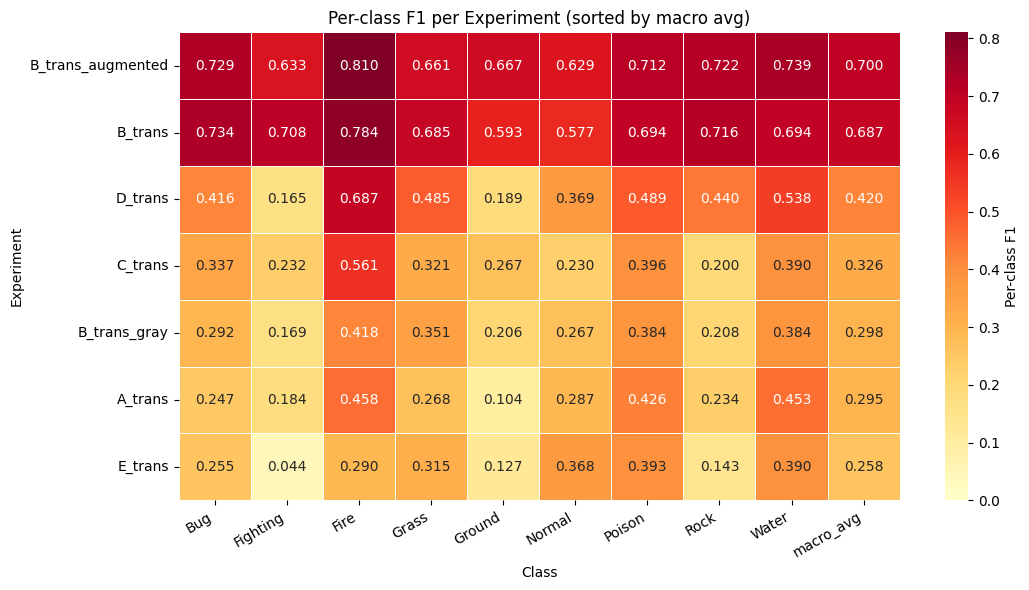

In [111]:
from src.evaluation.analysis import plot_per_class_f1_heatmap

# Build per-stem loader overrides dynamically:
# - stems ending in _gray_eq need build_loaders(grayscale=True, equalize=True)
# - stems ending in _gray (but not _gray_eq) need build_loaders(grayscale=True)
# - all other stems (RGB, augmented, extension) use the default build_loaders()
_loader_overrides = {}
for stem in model_registry:
    if stem.endswith("_gray_eq"):
        _loader_overrides[stem] = lambda: build_loaders(grayscale=True, equalize=True)
    elif stem.endswith("_gray"):
        _loader_overrides[stem] = lambda: build_loaders(grayscale=True)

fig = plot_per_class_f1_heatmap(
    checkpoint_dir=TASK_OUT_DIR / "checkpoints",
    model_registry={k: v["model"] for k, v in model_registry.items()},
    loader_fn=build_loaders,
    device=device,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_per_class_f1_heatmap.png",
    highlight_best=True,
    loader_fn_registry=_loader_overrides,
)
if fig:
    plt.show()
    plt.close(fig)

In [115]:
# ── Configure the ensemble here — only thing you need to touch ────────────────
# names  : checkpoint stems (must exist in model_registry above)
# weights: None = uniform average; [0.6, 0.4] = weighted (auto-normalised)

ENS = {
    "names":   ["B_trans_augmented", "D_trans"],
    "weights": [0.7, 0.3],
}

run_ensemble(ENS, print_leaderboard=True)


=== ENS_B_trans_augmented_D_trans ===
  B_trans_augmented              solo val_macro_f1 = 0.7002
  D_trans                        solo val_macro_f1 = 0.4198
  --- ensemble ---               val_macro_f1 = 0.7114  val_acc = 0.7125
  Delta vs best solo  : +0.0112


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_B_trans_augmented_D_trans,0.7114,0.7125,0,0.0
2,B_trans_augmented,0.7002,0.7028,30,507.2
3,B_trans,0.6873,0.6819,29,494.7
4,D_trans,0.4198,0.4486,22,131.2
5,C_trans,0.3260,0.3375,30,233.6
6,B_trans_gray,0.2977,0.3236,21,287.5
7,A_trans,0.2955,0.3333,28,182.7
8,E_trans,0.2583,0.3056,30,196.2
9,BestMLP-N_cosine_lr,0.2118,0.2444,14,77.3



  New overall best (ensemble) — regenerating submission CSV...
Submission saved: task3/outputs/results/submission_task3.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
  Submission updated -> task3/outputs/results/submission_task3.csv


TypeError: cannot unpack non-iterable NoneType object

## 3.2: All Models Summary
###### ──────────────────────────────────────────

=== All Experiments — Sorted by Val Macro-F1 ===



,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_B_trans_augmented_D_trans,0.7114,0.7125,0,0.0
2,B_trans_augmented,0.7002,0.7028,30,507.2
3,B_trans,0.6873,0.6819,29,494.7
4,D_trans,0.4198,0.4486,22,131.2
5,C_trans,0.3260,0.3375,30,233.6
6,B_trans_gray,0.2977,0.3236,21,287.5
7,A_trans,0.2955,0.3333,28,182.7
8,E_trans,0.2583,0.3056,30,196.2


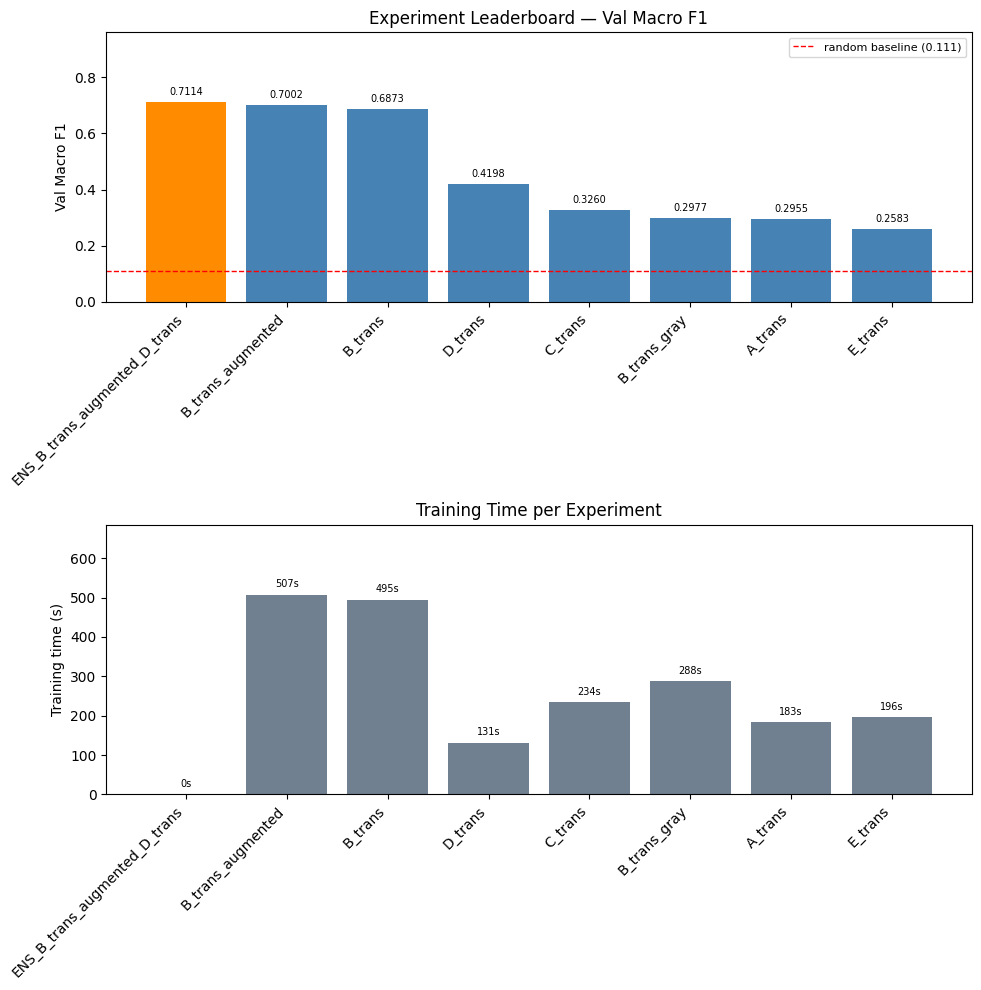

In [113]:
from src.evaluation.analysis import plot_leaderboard

# printed leaderboard table (same as before)
print("=== All Experiments — Sorted by Val Macro-F1 ===\n")
_print_leaderboard(results_tracker)

# bar chart (leaderboard + training time) saved to outputs/plots/
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard.png",
)
plt.show()
plt.close(fig)

## 3.3: Comparison Between Best Trans, CNN and MLP Models
###### ──────────────────────────────────────────

In [114]:
from src.models.mlp import MLP

model_MLP = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_MLP = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_MLP = torch.optim.Adam(model_MLP.parameters(), lr=LR)
scheduler_MLP = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_MLP, T_max=EPOCHS, eta_min=1e-5)

model_MLP, history_MLP = run_experiment(model_MLP, "BestMLP-N_cosine_lr", criterion_MLP, optimizer_MLP, scheduler_MLP, loaders_base)


  Experiment: BestMLP-N_cosine_lr
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.3002  train_f1=0.1267 | val_loss=2.2416  val_f1=0.0863 | 6.2s
  Epoch 02/30 | train_loss=2.2485  train_f1=0.0898 | val_loss=2.2334  val_f1=0.0714 | 4.8s
  Epoch 03/30 | train_loss=2.2343  train_f1=0.2087 | val_loss=2.2038  val_f1=0.1444 | 7.2s
  Epoch 04/30 | train_loss=2.1744  train_f1=0.2150 | val_loss=2.1751  val_f1=0.1406 | 4.8s
  Epoch 05/30 | train_loss=2.1367  train_f1=0.1902 | val_loss=2.2025  val_f1=0.1094 | 4.8s
  Epoch 06/30 | train_loss=2.0870  train_f1=0.2385 | val_loss=2.1585  val_f1=0.1339 | 6.2s
  Epoch 07/30 | train_loss=2.0531  train_f1=0.3285 | val_loss=2.1299  val_f1=0.2118 | 4.9s
  Epoch 08/30 | train_loss=2.0098  train_f1=0.3530 | val_loss=2.1473  val_f1=0.1750 | 6.1s
  Epoch 09/30 | train_loss=1.9405  train_f1=0.3919 | val_loss=2.1479  val_f1=0.1988 | 5.1s
  Epoch 10/30 | train_loss=1.8987  train_f1=0.4665 | val_loss=2.1588  val_f1=0.1981 | 4.8s
  Epoch 11/30 | train_loss=1.

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_B_trans_augmented_D_trans,0.7114,0.7125,0,0.0
2,B_trans_augmented,0.7002,0.7028,30,507.2
3,B_trans,0.6873,0.6819,29,494.7
4,D_trans,0.4198,0.4486,22,131.2
5,C_trans,0.3260,0.3375,30,233.6
6,B_trans_gray,0.2977,0.3236,21,287.5
7,A_trans,0.2955,0.3333,28,182.7
8,E_trans,0.2583,0.3056,30,196.2
9,BestMLP-N_cosine_lr,0.2118,0.2444,14,77.3


In [117]:
from src.models.cnn import DeepCNN

model_CNN = DeepCNN(in_channels=3, dropout=0.3).to(device)
criterion_CNN = nn.CrossEntropyLoss()
optimizer_CNN = torch.optim.Adam(model_CNN.parameters(), lr=LR)
scheduler_CNN = torch.optim.lr_scheduler.StepLR(optimizer_CNN, step_size=10, gamma=0.5)

model_CNN, history_CNN = run_experiment(model_CNN, "I_CNN", criterion_CNN, optimizer_CNN, scheduler_CNN, loaders_sampler)


  Experiment: I_CNN
  Model params: 206,889
  Epoch 01/30 | train_loss=2.0310  train_f1=0.2437 | val_loss=1.7716  val_f1=0.2559 | 5.1s
  Epoch 02/30 | train_loss=1.7116  train_f1=0.3057 | val_loss=1.6721  val_f1=0.2705 | 6.3s
  Epoch 03/30 | train_loss=1.3361  train_f1=0.5749 | val_loss=1.0925  val_f1=0.6011 | 5.1s
  Epoch 04/30 | train_loss=0.9176  train_f1=0.3949 | val_loss=2.4476  val_f1=0.3293 | 7.4s
  Epoch 05/30 | train_loss=0.7652  train_f1=0.5503 | val_loss=1.2991  val_f1=0.5344 | 6.2s
  Epoch 06/30 | train_loss=0.5208  train_f1=0.6354 | val_loss=0.9786  val_f1=0.5941 | 7.6s
  Epoch 07/30 | train_loss=0.4240  train_f1=0.2490 | val_loss=2.9737  val_f1=0.2372 | 5.8s
  Epoch 08/30 | train_loss=0.3578  train_f1=0.6475 | val_loss=0.8541  val_f1=0.6034 | 9.2s
  Epoch 09/30 | train_loss=0.2395  train_f1=0.0503 | val_loss=11.1068  val_f1=0.0402 | 6.9s
  Epoch 10/30 | train_loss=0.1862  train_f1=0.2949 | val_loss=4.5184  val_f1=0.2518 | 7.5s
  Epoch 11/30 | train_loss=0.0740  train_f1=

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,I_CNN,1.0000,1.0000,29,174.9
2,ENS_B_trans_augmented_D_trans,0.7114,0.7125,0,0.0
3,B_trans_augmented,0.7002,0.7028,30,507.2
4,B_trans,0.6873,0.6819,29,494.7
5,D_trans,0.4198,0.4486,22,131.2
6,C_trans,0.3260,0.3375,30,233.6
7,B_trans_gray,0.2977,0.3236,21,287.5
8,A_trans,0.2955,0.3333,28,182.7
9,E_trans,0.2583,0.3056,30,196.2



  New overall best — regenerating submission CSV...
Submission saved: task3/outputs/results/submission_task3.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
  Submission updated -> task3/outputs/results/submission_task3.csv


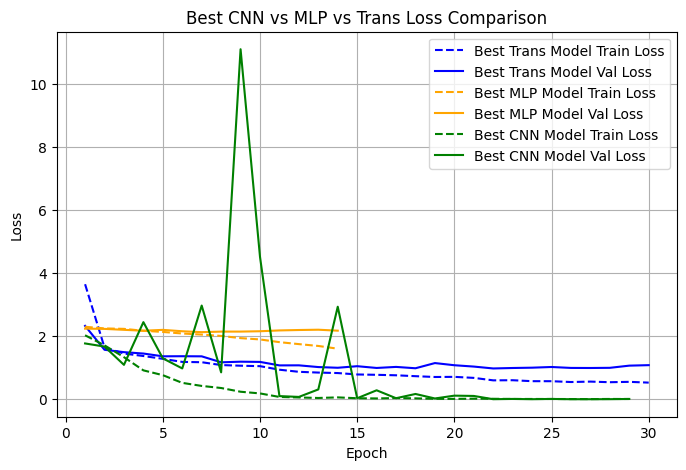

In [118]:
epochs_aug = range(1, len(history_aug["train_loss"]) + 1)
epochs_MLP = range(1, len(history_MLP["train_loss"]) + 1)
epochs_CNN = range(1, len(history_CNN["train_loss"]) + 1)

plt.figure(figsize=(8,5))

# Model 1
plt.plot(epochs_aug, history_aug["train_loss"], "--", label="Best Trans Model Train Loss", color="blue")
plt.plot(epochs_aug, history_aug["val_loss"], "-", label="Best Trans Model Val Loss", color="blue")

# Model 2
plt.plot(epochs_MLP, history_MLP["train_loss"], "--", label="Best MLP Model Train Loss", color="orange")
plt.plot(epochs_MLP, history_MLP["val_loss"], "-", label="Best MLP Model Val Loss", color="orange")

# Model 3
plt.plot(epochs_CNN, history_CNN["train_loss"], "--", label="Best CNN Model Train Loss", color="green")
plt.plot(epochs_CNN, history_CNN["val_loss"], "-", label="Best CNN Model Val Loss", color="green")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best CNN vs MLP vs Trans Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

## 3.4: Best (Solo) Model Deep Dive
###### ──────────────────────────────────────────

In [122]:
from src.evaluation.analysis import print_classification_report
from src.evaluation.ensemble import soft_ensemble

# ── Resolve model/criterion factories for ANY experiment name ─────────────────
# Static model_registry only holds the 19 base experiments (A-S).
# Variant names created by Part 3 (e.g. R_ls015_drop03_augmented, R_ls015_drop03_gray)
# are registered at runtime and may not survive a kernel restart.
# This helper derives the correct factory from the base stem so Part 4 is always robust.

_VARIANT_SUFFIXES = ("_augmented", "_gray_eq", "_gray")   # order matters: longest first

def _get_base_stem(name: str) -> str:
    """Strip variant suffix → base experiment name that lives in model_registry."""
    for sfx in _VARIANT_SUFFIXES:
        if name.endswith(sfx):
            return name[: -len(sfx)]
    return name

def _resolve_model_factory(name: str):
    """Return a zero-arg callable that creates the correct model architecture for *name*."""
    if name in model_registry:
        return model_registry[name]["model"]
    stem = _get_base_stem(name)
    if name.endswith("_gray") or name.endswith("_gray_eq"):
        return model_registry[stem]["model_gray"]
    return model_registry[stem]["model"]          # _augmented uses same RGB model

def _resolve_criterion_factory(name: str):
    """Return a zero-arg callable that creates the correct loss for *name*."""
    if name in model_registry:
        return model_registry[name]["criterion"]
    stem = _get_base_stem(name)
    return model_registry[stem]["criterion"]

# ── Helper: pick the right val/test loader for any model stem ─────────────────
def _get_loaders_for(stem: str):
    """Return (train_loader, val_loader) matching the input format of stem."""
    if stem.endswith("_gray_eq"):
        return build_loaders(grayscale=True, equalize=True)
    elif stem.endswith("_gray"):
        return build_loaders(grayscale=True)
    else:
        return build_loaders()

def _get_test_loader_for(stem: str):
    """Return a test DataLoader with the correct transform for stem."""
    from src.datasets.dataset import PokemonDataset, get_base_transforms, get_gray_transforms
    if stem.endswith("_gray_eq"):
        t = get_gray_transforms(IMG_SIZE, equalize=True)
    elif stem.endswith("_gray"):
        t = get_gray_transforms(IMG_SIZE, equalize=False)
    else:
        t = get_base_transforms(IMG_SIZE)
    ds = PokemonDataset(TEST_DIR, t, csv_path=None)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

def _run_test_inference(name: str) -> tuple:
    """
    Run the best model (solo or ensemble) on the test set.
    Returns (preds: list[int], test_loader: DataLoader).
    Uses soft_ensemble for both cases — same path as the training cells.
    """
    if name.startswith("ENS_"):
        # get member names from tracker (stored as child_models when ensemble was saved)
        member_names = results_tracker[name].get("child_models", [])
        print(f"Ensemble members: {member_names}")
        configs = [
            (_resolve_model_factory(n)(), TASK_OUT_DIR / "checkpoints" / f"{n}.pth")
            for n in member_names
        ]
        # ensemble members are always RGB — reuse global test_loader
        result = soft_ensemble(configs, test_loader, device, inference_mode=True)
        return result["preds"], test_loader
    else:
        tl = _get_test_loader_for(name)
        model = _resolve_model_factory(name)().to(device)
        model.load_state_dict(
            torch.load(TASK_OUT_DIR / "checkpoints" / f"{name}.pth", map_location=device, weights_only=True)
        )
        model.eval()
        preds = []
        with torch.no_grad():
            for imgs, _ in tl:
                preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().tolist())
        print(f"Solo model '{name}' — {len(preds)} test predictions collected.")
        return preds, tl


# Overall best (could be an ensemble) — used for final test predictions + submission
overall_best_name = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"\n - Overall best    : {overall_best_name}  (val_macro_f1={results_tracker[overall_best_name]['val_macro_f1']:.4f})")

# Best SOLO MODEL — for the history plot, confusion matrix, classification report.
# Excludes only ensembles (ENS_*); gray, augmented, and extension models are all valid winners.
best_name = max(
    (k for k in results_tracker if not k.startswith("ENS_")),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
best_name = "B_trans_augmented"
print(f" - Best solo model : {best_name}  (val_macro_f1={results_tracker[best_name]['val_macro_f1']:.4f})")



# ── Deep dive on best solo model ──────────────────────────────────────────────
print(" - per class scores:")
best_model     = _resolve_model_factory(best_name)().to(device)
best_criterion = _resolve_criterion_factory(best_name)()
best_model.load_state_dict(
    torch.load(TASK_OUT_DIR / "checkpoints" / f"{best_name}.pth", map_location=device, weights_only=True)
)

val_loader_final = _get_loaders_for(best_name)[1]

all_labels_list, all_preds = print_classification_report(best_model, val_loader_final, device, CLASSES)
val_metrics_final = evaluate(best_model, val_loader_final, best_criterion, device)
print(f" - val_loss={val_metrics_final['loss']:.4f}  val_acc={val_metrics_final['acc']:.4f}  macro_f1={val_metrics_final['macro_f1']:.4f}")


 - Overall best    : I_CNN  (val_macro_f1=1.0000)
 - Best solo model : B_trans_augmented  (val_macro_f1=0.7002)
 - per class scores:


,precision,recall,f1-score,support
Bug,0.720000,0.730000,0.730000,75.000000
Fighting,0.610000,0.660000,0.630000,58.000000
Fire,0.810000,0.820000,0.810000,76.000000
Grass,0.660000,0.670000,0.660000,60.000000
Ground,0.840000,0.550000,0.670000,49.000000
Normal,0.610000,0.650000,0.630000,121.000000
Poison,0.830000,0.620000,0.710000,93.000000
Rock,0.800000,0.660000,0.720000,53.000000
Water,0.670000,0.830000,0.740000,135.000000
accuracy,,,0.700000,720.000000


 - val_loss=1.0246  val_acc=0.7028  macro_f1=0.7002


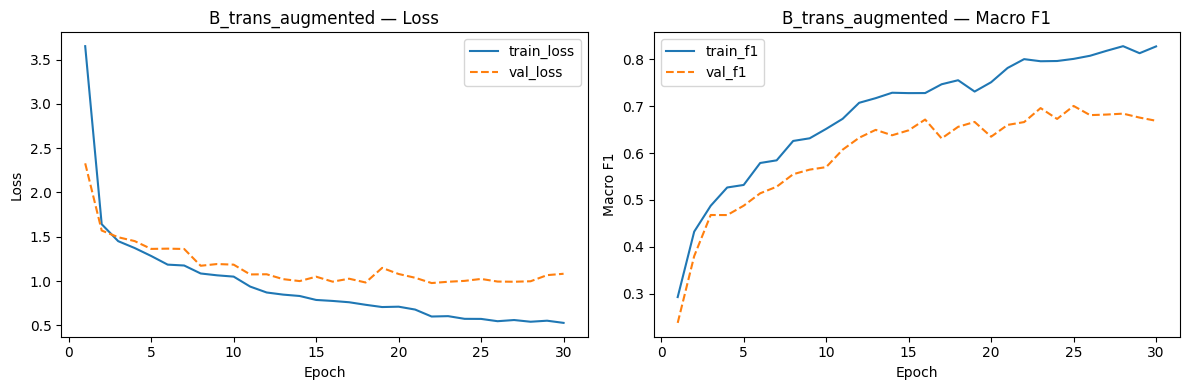

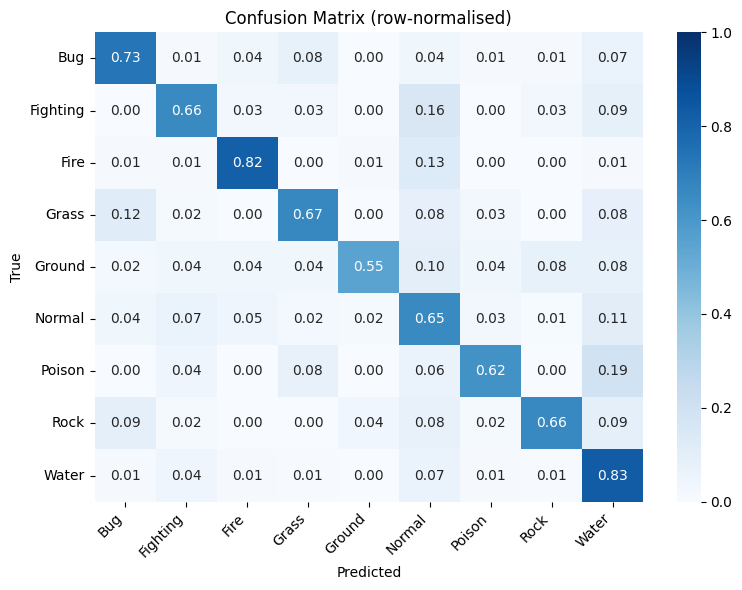

In [123]:
# ── Training curves + confusion matrix for best solo model
best_history = results_tracker[best_name]["history"]

fig = plot_history(best_history, TASK_OUT_DIR / "plots" / f"{TASK_NAME}_history.png", title=best_name)
plt.show(); plt.close(fig)

fig = plot_confusion_matrix(all_labels_list, all_preds, CLASSES, TASK_OUT_DIR / "plots" / f"{TASK_NAME}_confusion.png")
plt.show(); plt.close(fig)

# Final Summary & Submission

### Generate Submission with Best Model Overall on Test Set

In [125]:
# re-run the overall best model on the test set — confirms submission is up to date
# _run_test_inference handles both solo and ensemble via soft_ensemble (same as training cells)
overall_best_name = "ENS_B_trans_augmented_D_trans"
test_preds_final, final_test_loader = _run_test_inference(overall_best_name)
generate_submission_from_preds(final_test_loader, test_preds_final, CLASSES, SUB_PATH)
validate_submission(SUB_PATH)
print(f"Submission confirmed ({len(test_preds_final)} rows) -> {SUB_PATH}")

Ensemble members: ['B_trans_augmented', 'D_trans']
Submission saved: task3/outputs/results/submission_task3.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
Submission confirmed (900 rows) -> task3/outputs/results/submission_task3.csv


### Save output folder to disk/drive

In [128]:
# ── Save final outputs zip to Drive/local backup ──────────────────────────────
if USE_DRIVE:
    save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)
else:
    import shutil
    from google.colab import files
    print(f"[save_outputs] USE_DRIVE=False — outputs at: {TASK_OUT_DIR}")
    shutil.make_archive(TASK_OUT_DIR, 'zip', TASK_OUT_DIR)
    files.download(str(TASK_OUT_DIR) + '.zip')

[save_outputs] USE_DRIVE=False — outputs at: task3/outputs


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>